### Importing

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Bike_sharing.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


### EDA

In [58]:
df.shape

(730, 16)

In [59]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [60]:
# Feature Engineerig
df = df.rename(mapper = {"mnth" : "month"} , axis = 1)

df["dteday"] = pd.to_datetime(df["dteday"] , format = "%d-%m-%Y")

df.insert(loc = 2 , column = "day" , value =  df["dteday"].dt.day)
df.insert(loc = 3 , column = "year" , value = df["dteday"].dt.year)

df["year"] = df["year"].astype(np.int64)
df["day"] = df["day"].astype(np.int64)

In [61]:
# Dropping Columns
cols = ["dteday" , "yr" , "instant"]

for col in cols:
    df = df.drop(columns = col)

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.isnull().sum()

day           0
year          0
season        0
month         0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         730 non-null    int64  
 1   year        730 non-null    int64  
 2   season      730 non-null    int64  
 3   month       730 non-null    int64  
 4   holiday     730 non-null    int64  
 5   weekday     730 non-null    int64  
 6   workingday  730 non-null    int64  
 7   weathersit  730 non-null    int64  
 8   temp        730 non-null    float64
 9   atemp       730 non-null    float64
 10  hum         730 non-null    float64
 11  windspeed   730 non-null    float64
 12  casual      730 non-null    int64  
 13  registered  730 non-null    int64  
 14  cnt         730 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 85.7 KB


In [65]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,730.0,15.720548,8.802278,1.000000,8.000000,16.000000,23.000000,31.000000
year,730.0,2018.500000,0.500343,2018.000000,2018.000000,2018.500000,2019.000000,2019.000000
season,730.0,2.498630,1.110184,1.000000,2.000000,3.000000,3.000000,4.000000
month,730.0,6.526027,3.450215,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,730.0,0.028767,0.167266,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,730.0,2.997260,2.006161,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,730.0,0.683562,0.465405,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,730.0,1.394521,0.544807,1.000000,1.000000,1.000000,2.000000,3.000000
temp,730.0,20.319259,7.506729,2.424346,13.811885,20.465826,26.880615,35.328347
atemp,730.0,23.726322,8.150308,3.953480,16.889713,24.368225,30.445775,42.044800


In [67]:
df.describe()["cnt"]

count     730.000000
mean     4508.006849
std      1936.011647
min        22.000000
25%      3169.750000
50%      4548.500000
75%      5966.000000
max      8714.000000
Name: cnt, dtype: float64

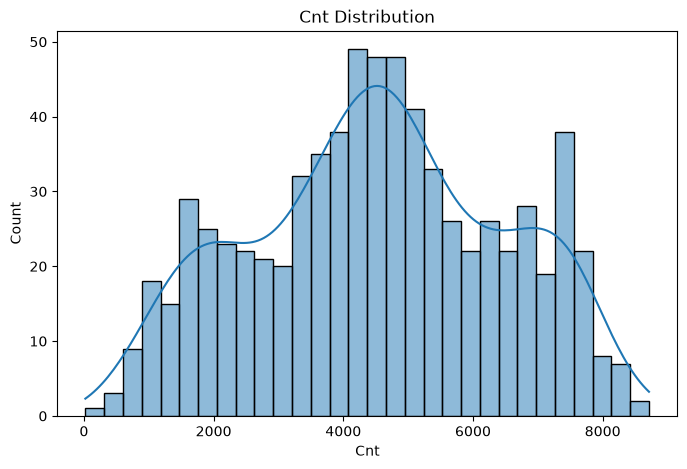

In [68]:
plt.figure(figsize = (8 , 5))
sns.histplot(df["cnt"] , bins = 30 , kde = True)

plt.title("Cnt Distribution")
plt.xlabel("Cnt")
plt.ylabel("Count")
plt.show()

In [69]:
df.corr()["cnt"].sort_values(ascending = False).drop("cnt").head(6)

registered    0.945411
casual        0.672123
atemp         0.630685
temp          0.627044
year          0.569728
season        0.404584
Name: cnt, dtype: float64

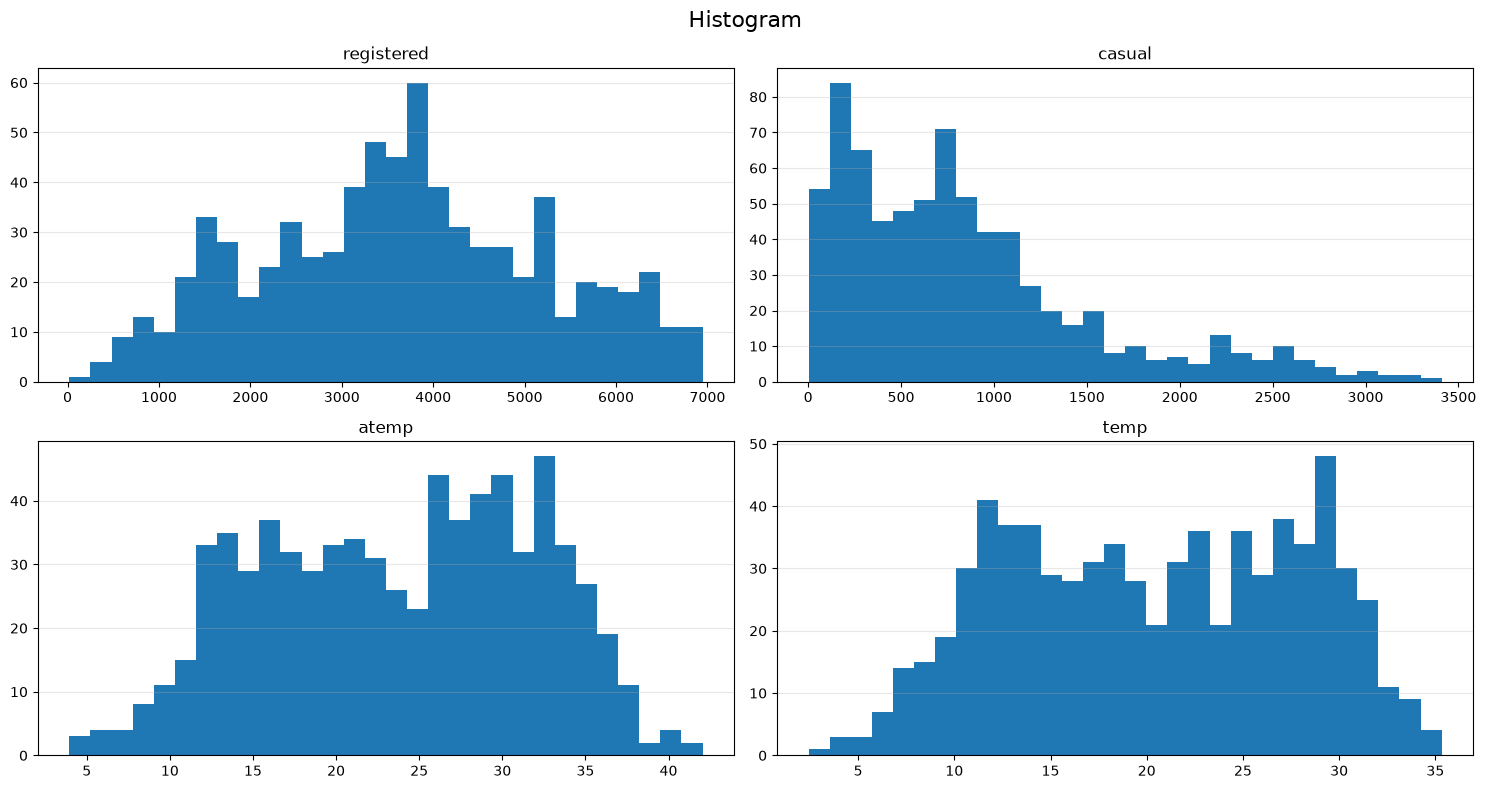

In [72]:
features = ["registered" , "casual" , "atemp" , "temp"]

fig , axes = plt.subplots(nrows = 2 , ncols = 2 , figsize = (15 , 8))

for ax , feature in zip(axes.flat , features):
    ax.hist(df[feature] , bins = 30)
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Histogram" , fontsize = 16)
plt.tight_layout()
plt.show()

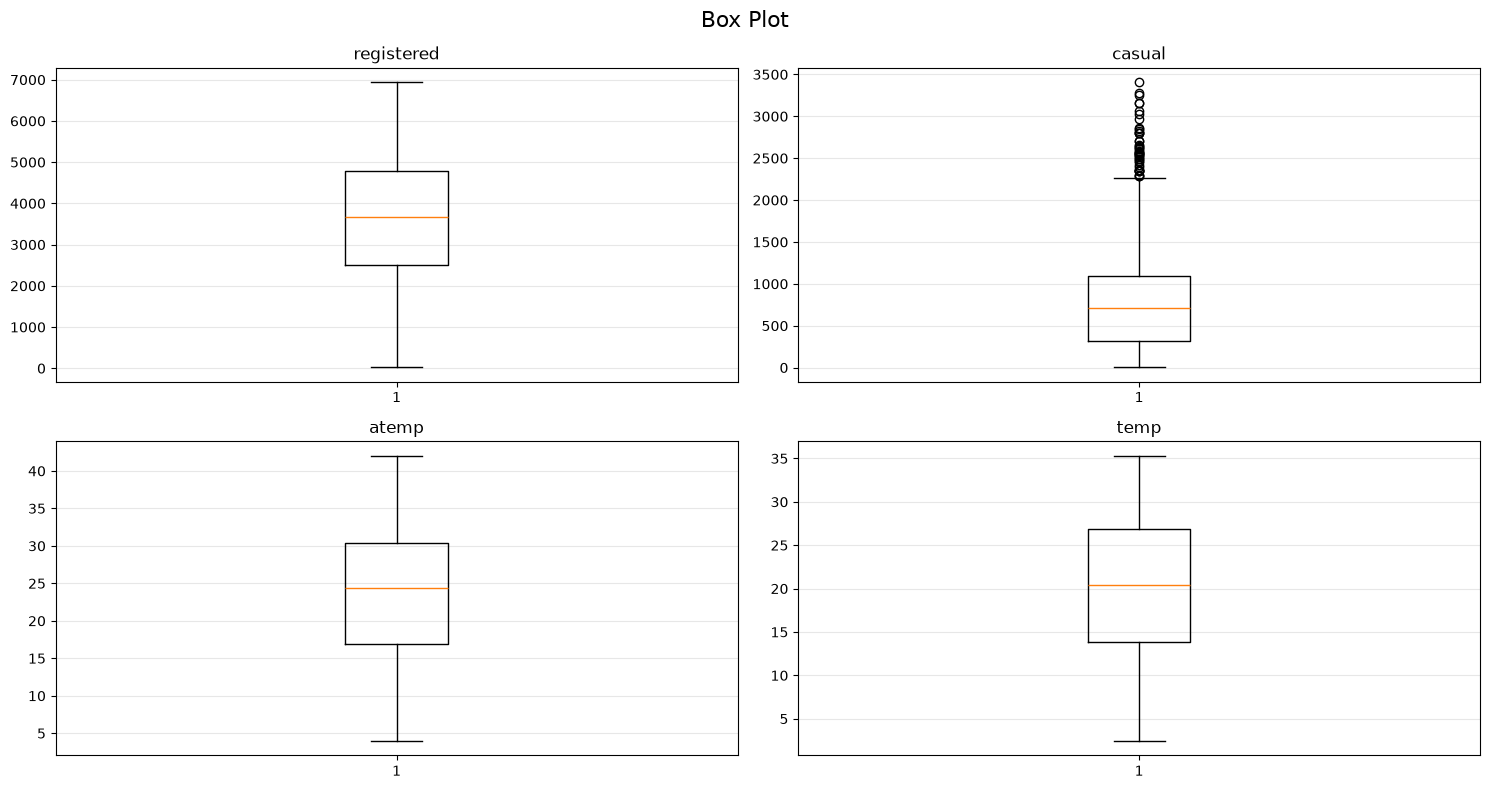

In [73]:
features = ["registered" , "casual" , "atemp" , "temp"]

fig , axes = plt.subplots(nrows = 2 , ncols = 2 , figsize = (15 , 8))

for ax , feature in zip(axes.flat , features):
    ax.boxplot(df[feature])
    ax.set_title(feature)
    ax.grid(axis = "y" , alpha = 0.3)

plt.suptitle("Box Plot" , fontsize = 16)
plt.tight_layout()
plt.show()

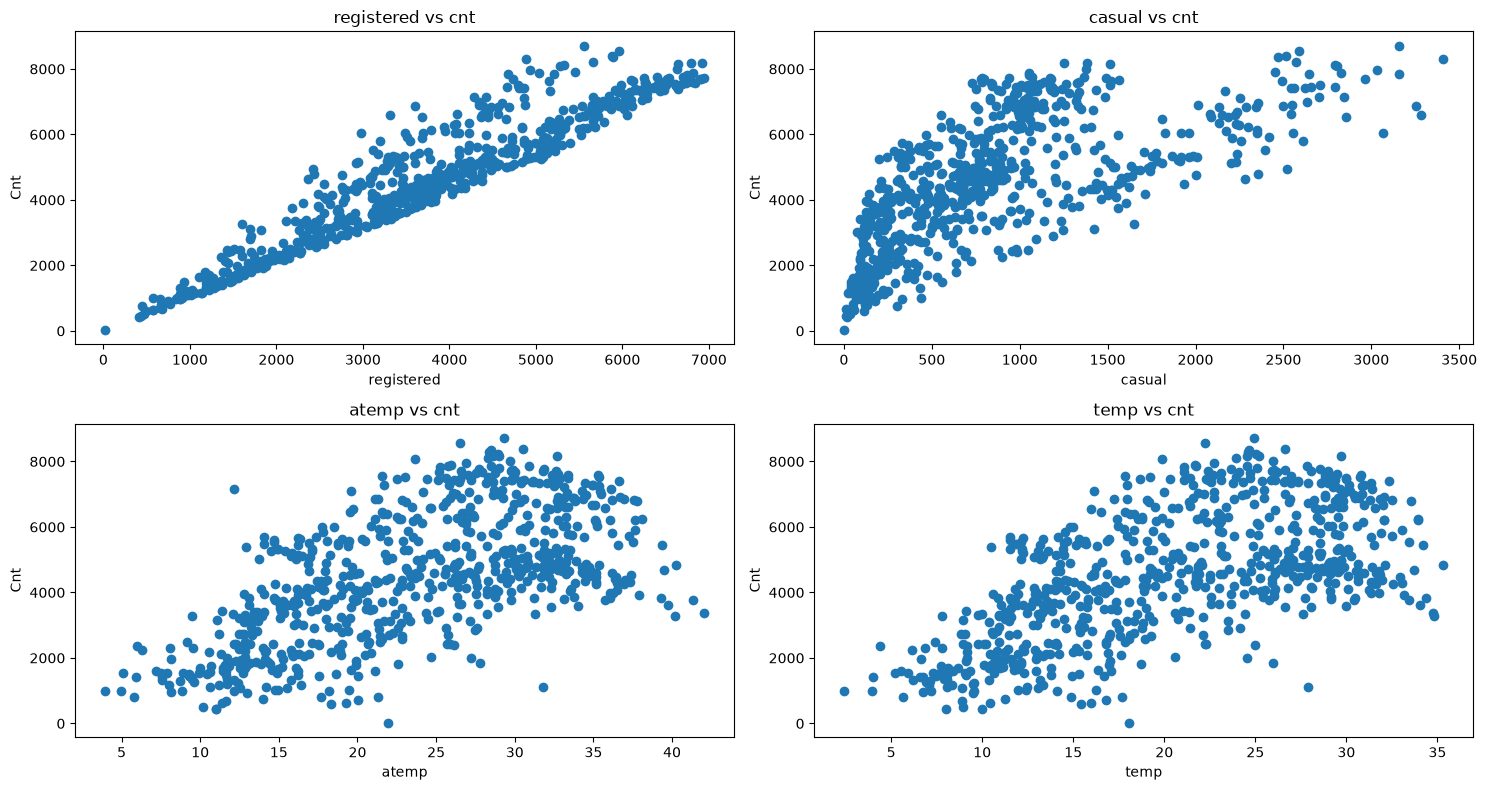

In [76]:
features = ["registered" , "casual" , "atemp" , "temp"]

fig , axes = plt.subplots(nrows = 2 , ncols = 2 , figsize = (15 , 8))

for ax , feature in zip(axes.flat , features):
    ax.scatter(df[feature] , df["cnt"])
    ax.set_xlabel(feature)
    ax.set_ylabel("Cnt")
    ax.set_title(f"{feature} vs cnt")

plt.tight_layout()
plt.show()

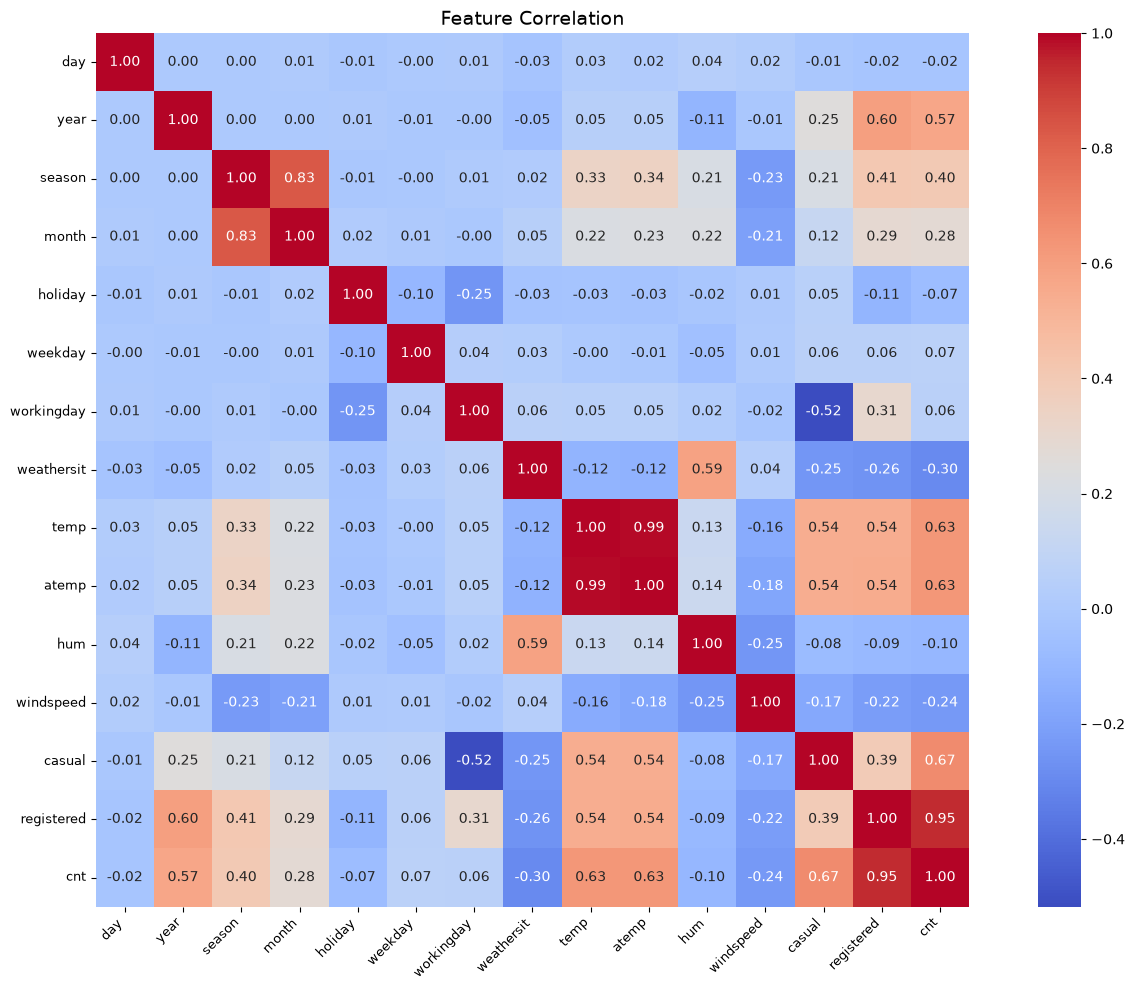

In [84]:
plt.figure(figsize = (14 , 10))
sns.heatmap(df.corr() , annot = True , square = True , cmap = "coolwarm" , fmt = ".2f")

plt.title("Feature Correlation" , fontsize = 14)
plt.xticks(rotation = 45 , ha = "right" , fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()

### Feature & Target Split

In [85]:
X = df.drop(columns = ["cnt"])
y = df["cnt"]

### Train & Test Split

In [87]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101)

### Model Training

In [89]:
model = RandomForestRegressor(random_state = 101)
model.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Prediction

In [90]:
y_pred = model.predict(X_test)

### Evaluation

In [91]:
print(f"Final Model : Random Forest Regressor")
print(f"MAE : {mean_absolute_error(y_test , y_pred)}")
print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 Score : {r2_score(y_test , y_pred)}")

Final Model : Random Forest Regressor
MAE : 82.2286301369863
MSE : 15452.195549315065
RMSE : 124.3068604273918
R2 Score : 0.9960560933834935


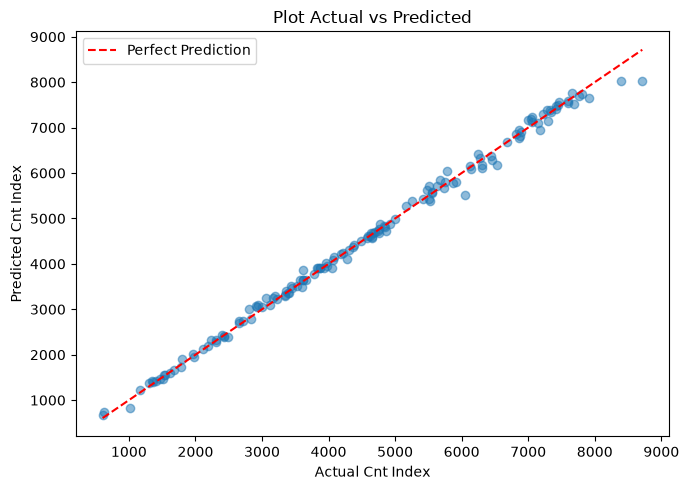

In [94]:
plt.figure(figsize = (7 , 5))
plt.scatter(y_test , y_pred , alpha = 0.5)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color = "red" , linestyle = "--" , label = "Perfect Prediction")

plt.title("Plot Actual vs Predicted")
plt.xlabel("Actual Cnt Index")
plt.ylabel("Predicted Cnt Index")
plt.tight_layout()
plt.legend()
plt.show()

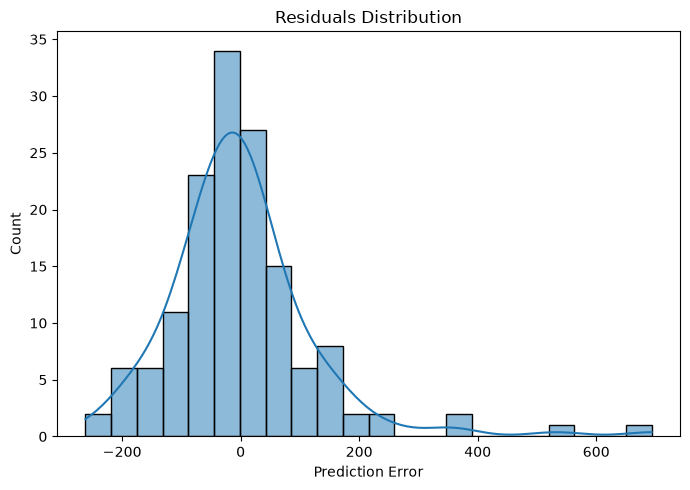

In [95]:
residuals = y_test - y_pred

plt.figure(figsize = (7 , 5))
sns.histplot(residuals , kde = True)

plt.title("Residuals Distribution")
plt.xlabel("Prediction Error")
plt.tight_layout()
plt.show()